# Polynomial Regression

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np

Now we import the data and take a look at it

In [2]:
df = pd.read_csv("FuelConsumptionCo2.csv")

df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


Now we select the features we want to use for regression

In [3]:
cdf = df[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_CITY","CO2EMISSIONS"]]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,CO2EMISSIONS
0,2.0,4,9.9,196
1,2.4,4,11.2,221
2,1.5,4,6.0,136
3,3.5,6,12.7,255
4,3.5,6,12.1,244
5,3.5,6,11.9,230
6,3.5,6,11.8,232
7,3.7,6,12.8,255
8,3.7,6,13.4,267


Plotting emission values with respect to engine size

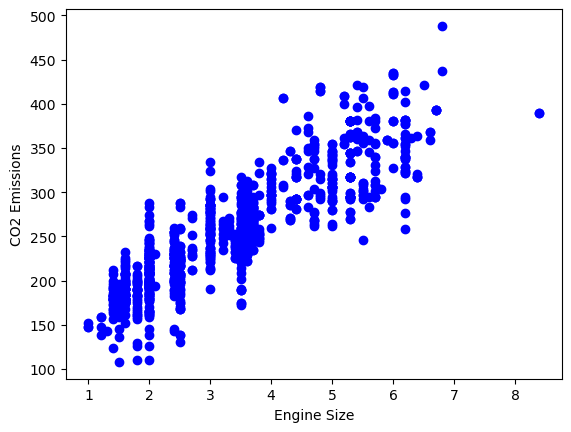

In [4]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color="blue")
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.show()

Split the data into training and testing set

In [5]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

Setting up the polynomial regression model

In [26]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

test_x = np.asanyarray(test[["ENGINESIZE"]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]])

poly = PolynomialFeatures(degree=2)
train_x_poly = poly.fit_transform(train_x)
train_x_poly


array([[ 1.  ,  2.  ,  4.  ],
       [ 1.  ,  2.4 ,  5.76],
       [ 1.  ,  1.5 ,  2.25],
       ...,
       [ 1.  ,  3.  ,  9.  ],
       [ 1.  ,  3.2 , 10.24],
       [ 1.  ,  3.2 , 10.24]], shape=(846, 3))

Now that we have an array of the entries of ranging from the power of 0 to the power of two, we will use this data in multiple regression model (notice that its the data entries that are the powers of x)

In [27]:
clf = linear_model.LinearRegression()
train_y = clf.fit(train_x_poly, train_y)
print("Coefficients: ", clf.coef_)
print("Intercept: ", clf.intercept_)

Coefficients:  [[ 0.         52.22456234 -1.72036344]]
Intercept:  [104.50022651]


Now that we have the intercept and the coefficients we can plot the grap

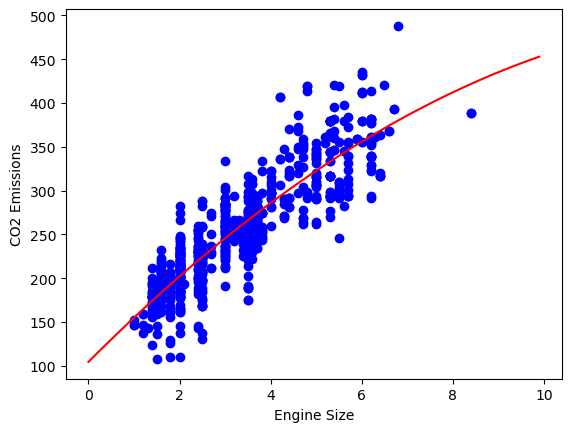

In [28]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color="blue")
XX = np.arange(0.0, 10.0, 0.1) #this is used to draw the red line in the plot
yy = clf.intercept_[0] + clf.coef_[0][1]*XX + clf.coef_[0][2]*np.power(XX, 2)
plt.plot(XX, yy, '-r')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.show()

# Evaluation

In [29]:
from sklearn.metrics import r2_score

test_x_ploy = poly.transform(test_x)
test_y_ = clf.predict(test_x_ploy)


print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y,test_y_ ) )

Mean absolute error: 25.18
Residual sum of squares (MSE): 1073.25
R2-score: 0.73


For cubic polynomial

In [44]:
cubic = PolynomialFeatures(degree=3)
train_x_cube = cubic.fit_transform(train_x)
train_x_cube

array([[ 1.   ,  2.   ,  4.   ,  8.   ],
       [ 1.   ,  2.4  ,  5.76 , 13.824],
       [ 1.   ,  1.5  ,  2.25 ,  3.375],
       ...,
       [ 1.   ,  3.   ,  9.   , 27.   ],
       [ 1.   ,  3.2  , 10.24 , 32.768],
       [ 1.   ,  3.2  , 10.24 , 32.768]], shape=(846, 4))

now we fit the regression line

In [42]:
train_y_cube = np.asanyarray(train[['CO2EMISSIONS']])
clf.fit(train_x_cube, train_y_cube)
print("Coefficients: ", clf.coef_)
print("Intercept: ", clf.intercept_)

Coefficients:  [[ 0.         33.27955302  3.49650809 -0.43177308]]
Intercept:  [124.59814861]


Ploting the graph

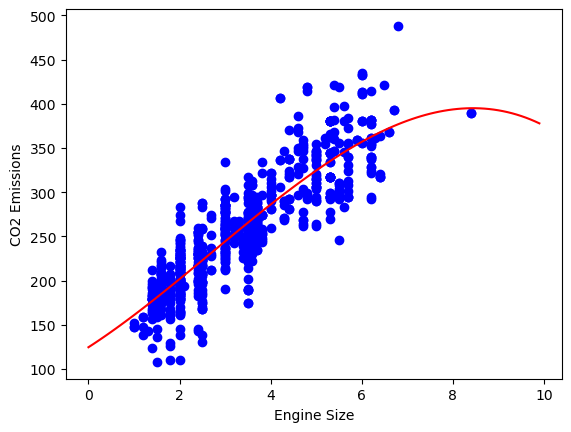

In [45]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color="blue")
XX = np.arange(0.0, 10.0, 0.1) #this is used to draw the red line in the plot
yy = clf.intercept_[0] + clf.coef_[0][1]*XX + clf.coef_[0][2]*np.power(XX, 2) + clf.coef_[0][3]*np.power(XX, 3)
plt.plot(XX, yy, '-r')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")
plt.show()

Evaluation

In [47]:
from sklearn.metrics import r2_score

test_x_cube = cubic.transform(test_x)
test_y_cube = clf.predict(test_x_cube)


print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_cube - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_cube - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y,test_y_cube ) )

Mean absolute error: 25.08
Residual sum of squares (MSE): 1068.29
R2-score: 0.73
